In [1]:
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=200, n_features=1, noise=15, random_state=42)

In [2]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

predictions = model.predict(X)

In [3]:
print(model.__dict__)

{'fit_intercept': True, 'copy_X': True, 'n_jobs': None, 'positive': False, 'n_features_in_': 1, 'coef_': array([87.1809762]), 'rank_': 1, 'singular_': array([13.13342643]), 'intercept_': 2.142770851531785}


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

In [5]:
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

In [6]:
model = nn.Linear(in_features=1, out_features=1)

In [7]:
criterion = nn.MSELoss()

In [8]:
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [9]:
epochs = 200

for epoch in range(epochs):

    predictions = model(X_tensor)

    loss = criterion(predictions, y_tensor)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if epoch % 20 == 0:
        print(epoch, loss.item())

0 6906.73486328125
20 3555.861572265625
40 1887.9881591796875
60 1056.9183349609375
80 642.4114990234375
100 435.4922790527344
120 332.1206970214844
140 280.4433288574219
160 254.5933074951172
180 241.65548706054688


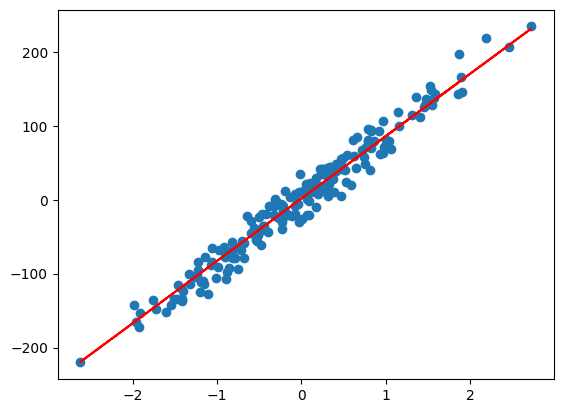

In [10]:
import matplotlib.pyplot as plt

with torch.no_grad():
    predictions = model(X_tensor)

plt.scatter(X, y)
plt.plot(X, predictions.numpy(), color="red")
plt.show()

In [27]:
from sklearn.datasets import make_classification
import numpy as np

X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=43,
)

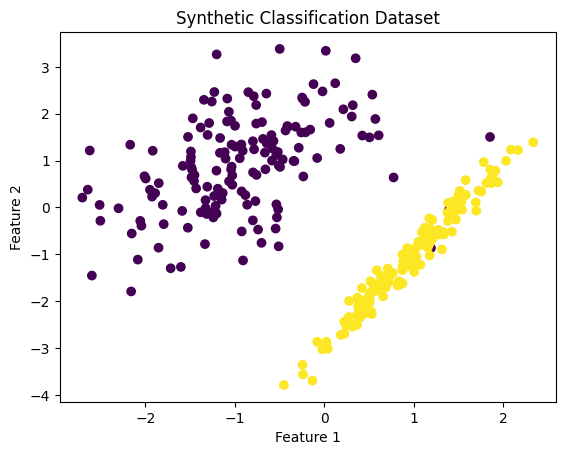

In [28]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Synthetic Classification Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [29]:
import torch

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

In [30]:
import torch.nn as nn

model = nn.Sequential(nn.Linear(2, 1), nn.Sigmoid())

In [31]:
criterion = nn.BCELoss()

In [32]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr=0.1)

In [33]:
epochs = 300

for epoch in range(epochs):

    preds = model(X_tensor)

    loss = criterion(preds, y_tensor)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if epoch % 50 == 0:
        print(epoch, loss.item())

0 0.9125952124595642
50 0.18887227773666382
100 0.12419245392084122
150 0.10240736603736877
200 0.09150475263595581
250 0.0849110558629036


In [34]:
with torch.no_grad():

    probs = model(X_tensor)

    predicted = (probs > 0.5).float()

In [35]:
print(predicted)

tensor([[0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
      

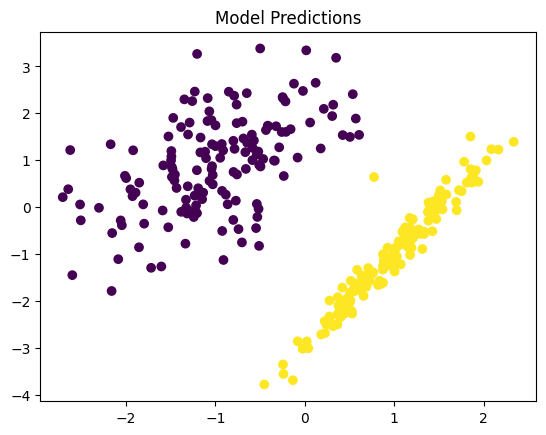

In [36]:
plt.scatter(X[:, 0], X[:, 1], c=predicted.numpy())
plt.title("Model Predictions")
plt.show()

In [37]:
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200),
)

grid = np.c_[xx.ravel(), yy.ravel()]

grid_tensor = torch.tensor(grid, dtype=torch.float32)

In [38]:
with torch.no_grad():
    probs = model(grid_tensor)

Z = probs.numpy().reshape(xx.shape)

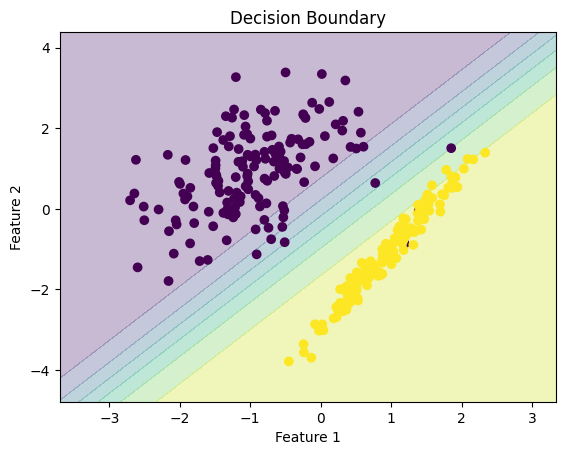

In [39]:
plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X[:, 0], X[:, 1], c=y)

plt.title("Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

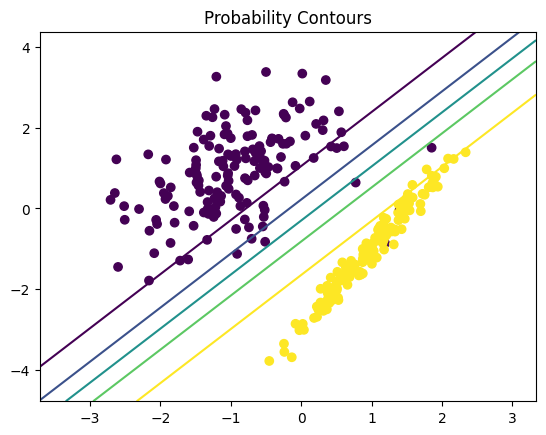

In [40]:
plt.contour(xx, yy, Z, levels=[0.1, 0.3, 0.5, 0.7, 0.9])

plt.scatter(X[:, 0], X[:, 1], c=y)

plt.title("Probability Contours")
plt.show()

In [41]:
print(model[0].weight)
print(model[0].bias)

Parameter containing:
tensor([[ 2.1827, -1.6268]], requires_grad=True)
Parameter containing:
tensor([-0.4923], requires_grad=True)
